<a href="https://colab.research.google.com/github/ivan-project-ml/linear_classification/blob/main/Hometask_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ivan-project-ml/linear_classification.git

Cloning into 'linear_classification'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 25 (delta 2), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 139.70 KiB | 1.32 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

**ЗАДАЧА КЛАССИФИКАЦИИ**

In [ ]:
names_ = np.array(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total','s/ns'])

dataset = pd.read_csv('/content/linear_classification/data/raw/spambase.data',
                      header=None,
                      names = names_)
dataset.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,s/ns
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 82.6 MB/s eta 0:00:00


In [ ]:
#Просто попробовал, к выполнению задания не относится
import sweetviz as sv
report = sv.analyze(dataset)
report.show_html('test_report')

                                             |          | [  0%]   00:00 -> (? left)

Report test_report was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
#Просто попробовал, к выполнению задания не относится
import sweetviz as sv
feat_cfg = sv.FeatureConfig(
    force_num = ['word_freq_857', 'word_freq_cs']
)
report = sv.compare_intra(
    dataset,
    dataset["spam/not spam"] == 1,
    ["Positive", "Negative"],
    feat_cfg=feat_cfg
)
report.show_html('second_test_report')

ModuleNotFoundError: No module named 'sweetviz'

In [ ]:
print(f'Размеры датасета: {dataset.shape}')
print(f'Число спам сообщений: {len(dataset[dataset['s/ns'] == 1])} \nЧисло не спам сообщений: {len(dataset[dataset['s/ns'] == 0])}')

Размеры датасета: (4601, 58)
Число спам сообщений: 1813 
Число не спам сообщений: 2788


Множество объектов X представляет собой множество сообщений, множество целевых признаков Y - метки spam (1) или not spam (0)

Признаковое описание объекта - вектор длины 57:
1. Первые 54 координаты - действительные числа из отрезка [0;100], отражающие частоту появления слова/символа в сообщении (в процентах)
2. Остальные 3 координаты показывают среднюю/максимальную/суммарную длину непрерывной последовательности заглавных букв

Визуальный анализ данных затруднён из-за длины признакового описания объекта, поэтому было решено отобрать наиболее значимые признаки и для них произвести визуальный анализ


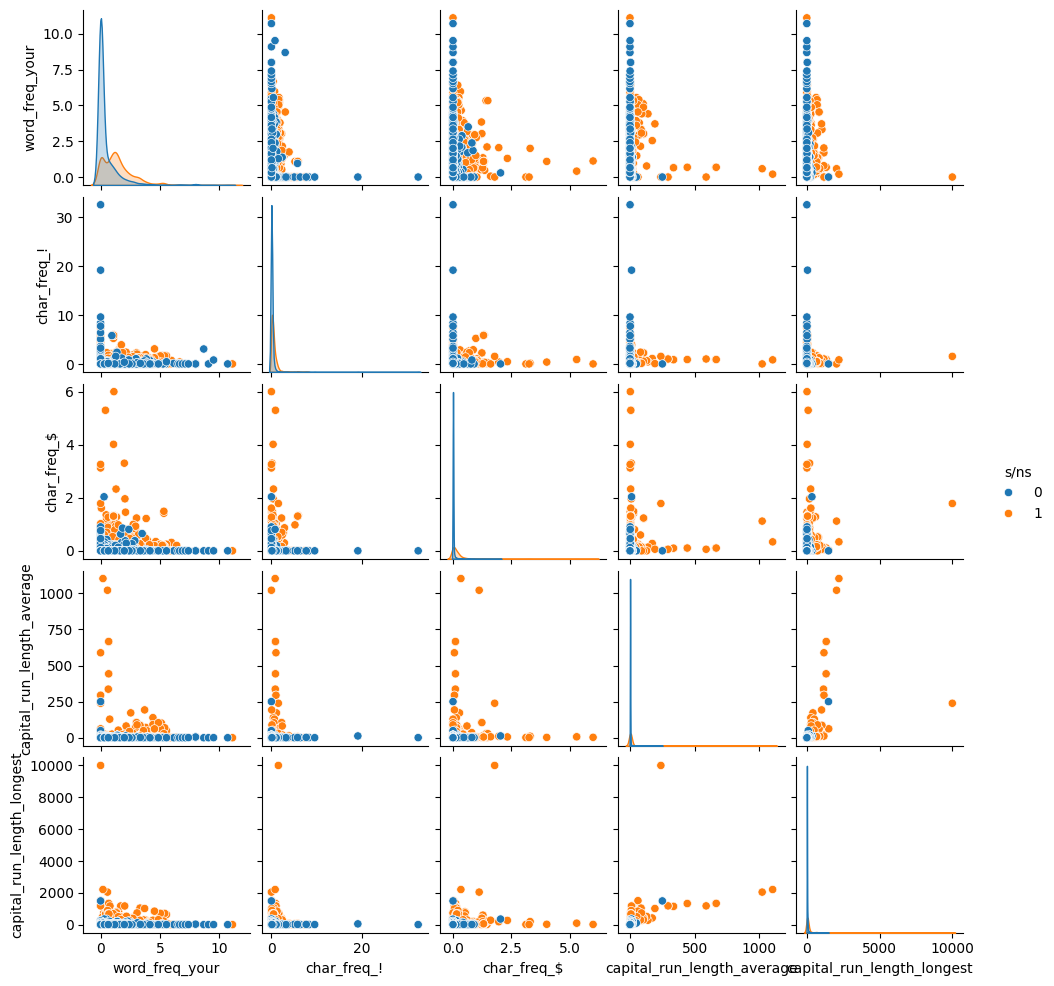

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
X,y = dataset.drop(columns = ['s/ns']), dataset['s/ns']
selector = SelectKBest(mutual_info_classif, k=5)
X_new = selector.fit_transform(X,y)
fs = X.columns[selector.get_support()]
df = pd.DataFrame(X_new, columns = fs)
df['s/ns'] = y.values
sns.pairplot(
    data = df,
    hue = 's/ns',
    height = 2
)
plt.show()

Проектирование наиболее информативных признаков (отобранных mutual_info_classif) на двумерные плоскости показывает, что признаки не могут быть легко разделены

Далее норимруем признаки и обучим модель логистической регрессии (baseline, без настройки гиперпараметров). Было решено использовать StandardScaler (позже будет проведено сравнение с немасштабрированными признаками и признаками, которые логарифмировали)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter = 1000, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921

[[506  25]
 [ 49 341]]


Далее подберём гиперпараметр, отвечающий за регуляризацию весов

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(
     Cs = 10,
     cv = 5,
     penalty = 'l2',
     scoring = 'f1',
     random_state = 42,
     max_iter = 1000
 )
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       531
           1       0.92      0.88      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921

[[502  29]
 [ 46 344]]


Особого улучшения метрик получено не было. Далее была обучена модель персептрона (линейного классификатора)

In [ ]:
from sklearn.linear_model import Perceptron

model = Perceptron()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87       531
           1       0.81      0.84      0.83       390

    accuracy                           0.85       921
   macro avg       0.85      0.85      0.85       921
weighted avg       0.85      0.85      0.85       921

[[454  77]
 [ 61 329]]


Для тренировки параметры были подобраны через сетку (хотя для линейной модели в этом нет как такового смысла из-за её простоты)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'penalty': [None, 'l2'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    Perceptron(max_iter=1000),
    param_grid = params,
    scoring = 'f1',
    n_jobs = -1,
    cv = 5
)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       531
           1       0.86      0.81      0.84       390

    accuracy                           0.87       921
   macro avg       0.87      0.86      0.86       921
weighted avg       0.87      0.87      0.86       921

[[481  50]
 [ 74 316]]


**ЗАДАЧА РЕГРЕССИИ**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('/content/linear_classification/data/raw/forestfires.csv')
print(dataset.shape)
dataset.head()

(517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


Набор данных содержит всего 517 наблюдений и 12 аттрибутов + 1 целевой, поэтому можно попробовать использовать ydata (сейчас fg-data)

In [8]:
!pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00


In [12]:
from data_profiling import ProfileReport
profile = ProfileReport(dataset, title='test_reg_report')
profile.to_file('Regress_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 78.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Анализ данных показал, что в датасете присутствует 2 основные проблемы:
1. Высокая корреляция части данных
2. Для 98% наблюдений rain = 0

Корреляция данных вполне естественна, так как индексы FWI рассчитываются на основе температуры воздуха, его влажности и тд., однако интересно, что показатели DC и month также коррелированы

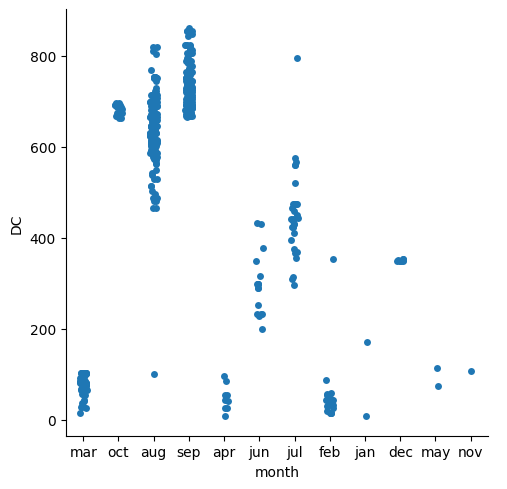

In [20]:
data = dataset[["month", "DC"]]
sns.catplot(
    data = data,
    x = "month",
    y = "DC"
)

Зная, что индекс DC характеризует содержание влаги в плотных слоя почвы, можно считать, что подобная корреляция вполне естетсвенна.

Номинальные признаки будут закодированы с помощью OneHotEncoder

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(sparse_output = False)
en_data = encoder.fit_transform(dataset[['month', 'day']])
en_df = pd.DataFrame(
    data = en_data,
    columns = encoder.get_feature_names_out(['month', 'day'])
)

dataset_ = dataset.drop(columns = ['month', 'day'])
dataset = pd.concat([en_df, dataset_], axis = 1)

feature_lst = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
ct = ColumnTransformer(
    [('scaler', StandardScaler(), feature_lst)],
    remainder = 'passthrough'
)

KeyError: "None of [Index(['month', 'day'], dtype='object')] are in the [columns]"

In [7]:
feature_lst = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
ct = ColumnTransformer(
    [('scaler', StandardScaler(), feature_lst)],
    remainder = 'passthrough'
)

Далее обучим модель линейной регрессии (таргеты были логарифмированы, так как их распределение сильно скошено вправо)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

model = LinearRegression()

X, y = dataset.drop(columns = ['area']), dataset['area']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
y_train = np.log1p(y_train)

model.fit(X_train, y_train)

LinearRegression()

In [9]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_test)
y_pred = np.expm1(y_pred)

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 20.106849297792458
RMSE: 109.79930106178487
R^2: -0.0227459962460006


Модель вышла плохой, могу связать это с мультиколлинеарностью исходных данных. Следует рассмотреть модели с регуляризацией (или метрические методы)

